In [ ]:
import torch

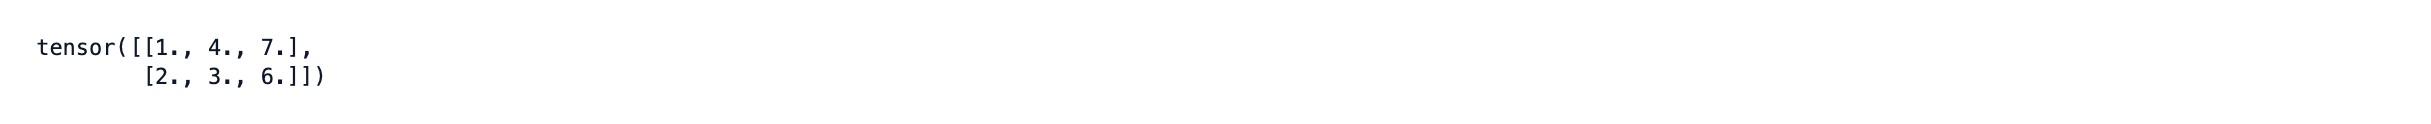

In [ ]:
X = torch.tensor([[1.0, 4.0, 7.0], [2.0, 3.0, 6.0]])
X

In [ ]:
print(X.shape)
print(X.dtype)

torch.Size([2, 3])
torch.float32


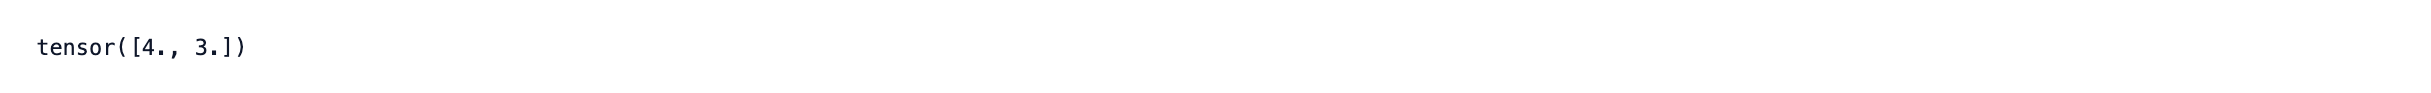

In [ ]:
X[:, 1]

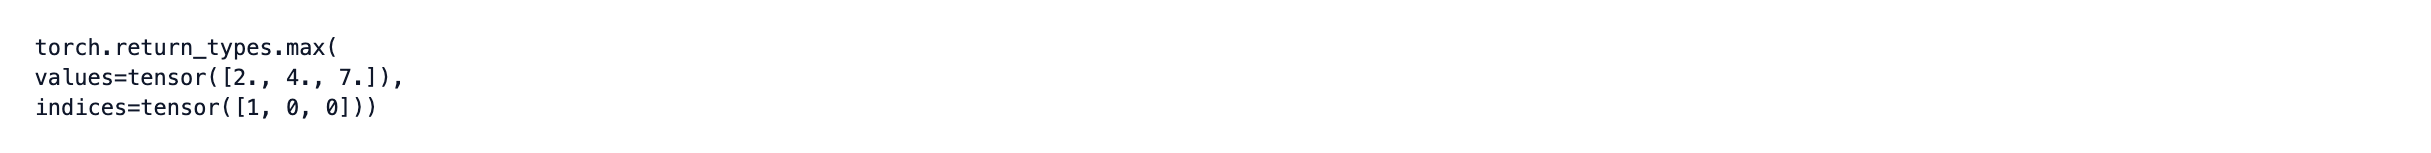

In [ ]:
X.max(dim=0)

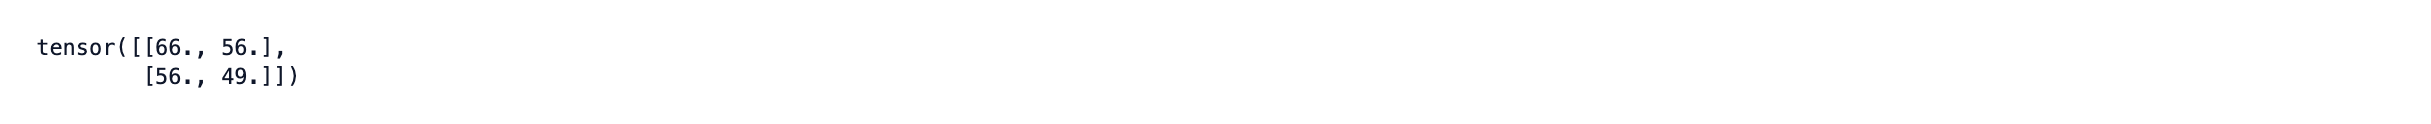

In [ ]:
X @ X.T

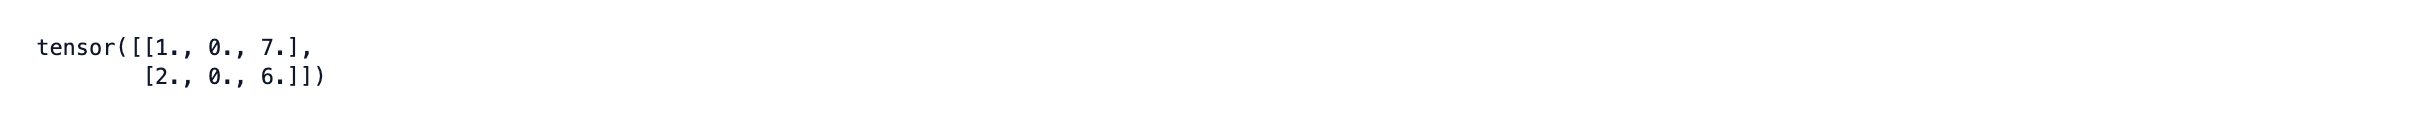

In [ ]:
X[:, 1] = -42
X.relu_()

In [ ]:
import timeit

device = "mps"

M = torch.rand((5000, 5000))
print(timeit.timeit("M @ M.T", globals=globals(), number=10))

M = torch.rand((5000, 5000), device=device)
print(timeit.timeit("M @ M.T", globals=globals(), number=10))

1.0915113331284374
0.0037314160726964474


In [ ]:
x = torch.tensor(5.0, requires_grad=True)
_lr = 0.1

for iteration in range(100):
    f = x ** 2
    f.backward()
    with torch.no_grad():
        x -= _lr * x.grad

    x.grad.zero_()

    print(x)

tensor(4., requires_grad=True)
tensor(3.2000, requires_grad=True)
tensor(2.5600, requires_grad=True)
tensor(2.0480, requires_grad=True)
tensor(1.6384, requires_grad=True)
tensor(1.3107, requires_grad=True)
tensor(1.0486, requires_grad=True)
tensor(0.8389, requires_grad=True)
tensor(0.6711, requires_grad=True)
tensor(0.5369, requires_grad=True)
tensor(0.4295, requires_grad=True)
tensor(0.3436, requires_grad=True)
tensor(0.2749, requires_grad=True)
tensor(0.2199, requires_grad=True)
tensor(0.1759, requires_grad=True)
tensor(0.1407, requires_grad=True)
tensor(0.1126, requires_grad=True)
tensor(0.0901, requires_grad=True)
tensor(0.0721, requires_grad=True)
tensor(0.0576, requires_grad=True)
tensor(0.0461, requires_grad=True)
tensor(0.0369, requires_grad=True)
tensor(0.0295, requires_grad=True)
tensor(0.0236, requires_grad=True)
tensor(0.0189, requires_grad=True)
tensor(0.0151, requires_grad=True)
tensor(0.0121, requires_grad=True)
tensor(0.0097, requires_grad=True)
tensor(0.0077, requires_

In [ ]:
t = torch.tensor(2.0, requires_grad=True)
z = t.exp()
z = z + 1
z.backward()

In [ ]:
# Linear regression with tensors and autograd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data,
    housing.target,
    random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    random_state=42
)

# Convert to tensors
X_train = torch.FloatTensor(X_train)
X_valid = torch.FloatTensor(X_valid)
X_test = torch.FloatTensor(X_test)

means = X_train.mean(dim=0, keepdim=True)
stds = X_train.std(dim=0, keepdim=True)

# Normalization
X_train = (X_train - means) / stds
X_valid = (X_valid - means) / stds
X_test = (X_test - means) / stds

# Convert targets to tensors
y_train = torch.FloatTensor(y_train).reshape(-1, 1)
y_valid = torch.FloatTensor(y_valid).reshape(-1, 1)
y_test = torch.FloatTensor(y_test).reshape(-1, 1)

In [ ]:
# Prepare parameters for linear regression model

torch.manual_seed(42)
n_features = X_train.shape[1]
w = torch.randn((n_features, 1), requires_grad=True)
b = torch.tensor(0., requires_grad=True)

lr = 0.05
n_epoches = 500

for epoch in range(n_epoches):
    y_pred = X_train @ w + b
    loss = ((y_pred - y_train) ** 2).mean()
    loss.backward()

    with torch.no_grad():
        b -= lr * b.grad
        w -= lr * w.grad
        b.grad.zero_()
        w.grad.zero_()
    print(f"Epoch {epoch + 1} / {n_epoches}, Loss: {loss.item()}")

Epoch 1 / 500, Loss: 16.158458709716797
Epoch 2 / 500, Loss: 11.550877571105957
Epoch 3 / 500, Loss: 8.44035816192627
Epoch 4 / 500, Loss: 6.3165602684021
Epoch 5 / 500, Loss: 4.847929000854492
Epoch 6 / 500, Loss: 3.8180854320526123
Epoch 7 / 500, Loss: 3.0850610733032227
Epoch 8 / 500, Loss: 2.555102586746216
Epoch 9 / 500, Loss: 2.1658284664154053
Epoch 10 / 500, Loss: 1.8753596544265747
Epoch 11 / 500, Loss: 1.6552951335906982
Epoch 12 / 500, Loss: 1.486151099205017
Epoch 13 / 500, Loss: 1.3543915748596191
Epoch 14 / 500, Loss: 1.2504830360412598
Epoch 15 / 500, Loss: 1.1676151752471924
Epoch 16 / 500, Loss: 1.1008497476577759
Epoch 17 / 500, Loss: 1.0465542078018188
Epoch 18 / 500, Loss: 1.0020184516906738
Epoch 19 / 500, Loss: 0.9651924967765808
Epoch 20 / 500, Loss: 0.9345076680183411
Epoch 21 / 500, Loss: 0.9087489247322083
Epoch 22 / 500, Loss: 0.8869664072990417
Epoch 23 / 500, Loss: 0.8684110045433044
Epoch 24 / 500, Loss: 0.8524871468544006
Epoch 25 / 500, Loss: 0.838718950

In [ ]:
X_new = X_test[:3]
with torch.no_grad():
    _y_pred = X_new @ w + b
print(_y_pred)

tensor([[0.7282],
        [1.7676],
        [2.7740]])


In [ ]:
# Linear regression with high-level API

import torch.nn as nn

torch.manual_seed(42)

model = nn.Linear(in_features=n_features, out_features=1)
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
mse = nn.MSELoss()

In [ ]:
def train_bgd(model, optimizer, criterion, X_train, y_train, n_epoches):
    for epoch in range(n_epoches):
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        print(f"Epoch {epoch + 1}/{n_epoches}, Loss: {loss.item()}")

In [ ]:
train_bgd(model, optimizer, mse, X_train, y_train, n_epoches)

Epoch 1/500, Loss: 0.5248323082923889
Epoch 2/500, Loss: 0.5248299837112427
Epoch 3/500, Loss: 0.5248276591300964
Epoch 4/500, Loss: 0.5248253345489502
Epoch 5/500, Loss: 0.5248231291770935
Epoch 6/500, Loss: 0.524820864200592
Epoch 7/500, Loss: 0.5248186588287354
Epoch 8/500, Loss: 0.5248163938522339
Epoch 9/500, Loss: 0.524814248085022
Epoch 10/500, Loss: 0.5248121023178101
Epoch 11/500, Loss: 0.5248098969459534
Epoch 12/500, Loss: 0.5248078107833862
Epoch 13/500, Loss: 0.5248057842254639
Epoch 14/500, Loss: 0.5248036980628967
Epoch 15/500, Loss: 0.5248016119003296
Epoch 16/500, Loss: 0.524799644947052
Epoch 17/500, Loss: 0.5247976779937744
Epoch 18/500, Loss: 0.5247955918312073
Epoch 19/500, Loss: 0.5247936844825745
Epoch 20/500, Loss: 0.5247917175292969
Epoch 21/500, Loss: 0.5247898697853088
Epoch 22/500, Loss: 0.524787962436676
Epoch 23/500, Loss: 0.5247860550880432
Epoch 24/500, Loss: 0.5247842073440552
Epoch 25/500, Loss: 0.5247824192047119
Epoch 26/500, Loss: 0.5247805714607239

In [ ]:
_X_new = X_test[:3]

with torch.no_grad():
    _y_pred = model(_X_new)

print(_y_pred)

tensor([[0.7172],
        [1.7763],
        [2.7683]])


In [ ]:
torch.manual_seed(42)

MLP_model = nn.Sequential(
    nn.Linear(n_features, 50),
    nn.ReLU(),
    nn.Linear(50, 40),
    nn.ReLU(),
    nn.Linear(40, 1)
)

In [ ]:
MLP_lr = 0.01
MLP_opt = torch.optim.SGD(MLP_model.parameters(), lr=MLP_lr)

In [ ]:
train_bgd(MLP_model, MLP_opt, mse, X_train, y_train, n_epoches)

Epoch 1/500, Loss: 5.045480251312256
Epoch 2/500, Loss: 4.68717622756958
Epoch 3/500, Loss: 4.346471309661865
Epoch 4/500, Loss: 4.020055770874023
Epoch 5/500, Loss: 3.706490993499756
Epoch 6/500, Loss: 3.4053335189819336
Epoch 7/500, Loss: 3.117288827896118
Epoch 8/500, Loss: 2.8437368869781494
Epoch 9/500, Loss: 2.5865440368652344
Epoch 10/500, Loss: 2.3477840423583984
Epoch 11/500, Loss: 2.129230260848999
Epoch 12/500, Loss: 1.9320870637893677
Epoch 13/500, Loss: 1.7571256160736084
Epoch 14/500, Loss: 1.6041170358657837
Epoch 15/500, Loss: 1.4722553491592407
Epoch 16/500, Loss: 1.3601948022842407
Epoch 17/500, Loss: 1.2660672664642334
Epoch 18/500, Loss: 1.1877902746200562
Epoch 19/500, Loss: 1.1231715679168701
Epoch 20/500, Loss: 1.0700280666351318
Epoch 21/500, Loss: 1.026275873184204
Epoch 22/500, Loss: 0.9901183843612671
Epoch 23/500, Loss: 0.9600398540496826
Epoch 24/500, Loss: 0.9347695112228394
Epoch 25/500, Loss: 0.913277804851532
Epoch 26/500, Loss: 0.8947466015815735
Epoch

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

GPU_X_train = X_train.to(device)
GPU_y_train = y_train.to(device)

train_dataset = TensorDataset(GPU_X_train, GPU_y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [ ]:
torch.manual_seed(42)

GPU_MLP_model = nn.Sequential(
    nn.Linear(n_features, 50),
    nn.ReLU(),
    nn.Linear(50, 40),
    nn.ReLU(),
    nn.Linear(40, 1)
)

GPU_MLP_model = GPU_MLP_model.to(device)

GPU_MLP_opt = torch.optim.SGD(GPU_MLP_model.parameters(), lr=MLP_lr)

In [ ]:
# Mini-batch GD

def train(model, optimizer, criterion, train_loader, n_epoches):
    model.train()
    for epoch in range(n_epoches):
        total_loss = 0.
        for X_batch, y_batch in train_loader:
            # X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)

            loss = criterion(y_pred, y_batch)
            total_loss += loss.detach()

            loss.backward()
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

        # mean_loss = total_loss / len(train_loader)
        mean_loss = (total_loss / len(train_loader)).item()
        print(f"Epoch {epoch + 1}/{n_epoches}, Loss: {mean_loss:.4f}")

In [ ]:
train(GPU_MLP_model, GPU_MLP_opt, mse, train_loader, 20)

Epoch 1/20, Loss: 0.6958
Epoch 2/20, Loss: 0.4480
Epoch 3/20, Loss: 0.4039
Epoch 4/20, Loss: 0.3843
Epoch 5/20, Loss: 0.3708
Epoch 6/20, Loss: 0.3648
Epoch 7/20, Loss: 0.3556
Epoch 8/20, Loss: 0.3520
Epoch 9/20, Loss: 0.3488
Epoch 10/20, Loss: 0.3461
Epoch 11/20, Loss: 0.3412
Epoch 12/20, Loss: 0.3381
Epoch 13/20, Loss: 0.3358
Epoch 14/20, Loss: 0.3315
Epoch 15/20, Loss: 0.3319
Epoch 16/20, Loss: 0.3287
Epoch 17/20, Loss: 0.3271
Epoch 18/20, Loss: 0.3249
Epoch 19/20, Loss: 0.3291
Epoch 20/20, Loss: 0.3229


In [ ]:
# Model eval

def evaluate(model, data_loader, metric_fn, aggregate_fn=torch.mean):
    model.eval()
    metrics = []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric = metric_fn(y_pred, y_batch)
            metrics.append(metric)

    return aggregate_fn(torch.stack(metrics))

In [ ]:
valid_dataset = TensorDataset(X_valid, y_valid)
valid_loader = DataLoader(valid_dataset, batch_size=32)
valid_mse = evaluate(GPU_MLP_model, valid_loader, mse)

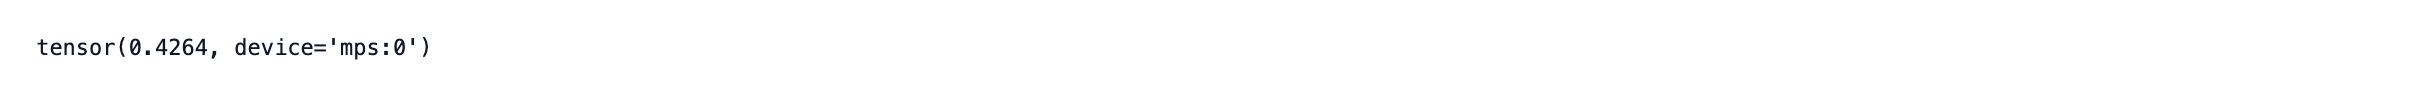

In [ ]:
valid_mse

In [ ]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

In [ ]:
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)

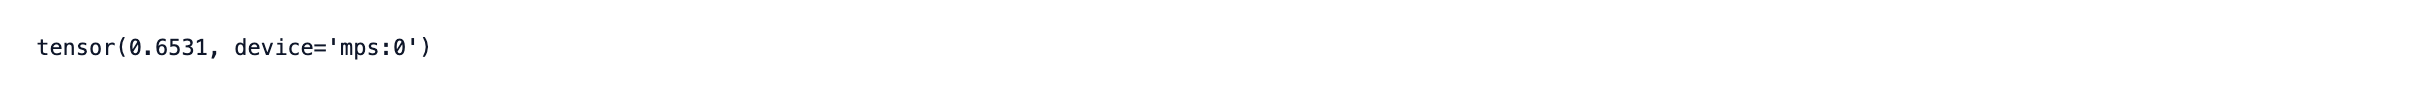

In [ ]:
evaluate_tm(GPU_MLP_model, valid_loader, rmse)

In [ ]:
print(GPU_MLP_model(X_train[:5].to(device)))

print(y_pred[:5])

tensor([[2.6032],
        [1.8802],
        [2.0699],
        [3.3100],
        [0.9289]], device='mps:0', grad_fn=<LinearBackward0>)
tensor([[2.5139],
        [2.1334],
        [2.1449],
        [3.2684],
        [0.7368]], grad_fn=<SliceBackward0>)


In [ ]:
# Non-sequential model (Wild & Deep)

class WideAndDeep(nn.Module):

    def __init__(self, n_features):
        super().__init__()

        self.deep_stack = nn.Sequential(
            nn.Linear(n_features, 50),
            nn.ReLU(),
            nn.Linear(50, 40),
            nn.ReLU(),
        )
        self.output_layer = nn.Linear(40 + n_features, 1)

    def forward(self, X):
        deep_output = self.deep_stack(X)
        wide_and_deep = torch.concat([X, deep_output], dim=1)
        return self.output_layer(wide_and_deep)

In [ ]:
torch.manual_seed(42)
WAD_model = WideAndDeep(n_features).to(device)
WAD_lr = 0.002
WAD_opt = torch.optim.SGD(WAD_model.parameters(), lr=WAD_lr)

In [ ]:
train(WAD_model, WAD_opt, mse, train_loader, 25)

Epoch 1/25, Loss: 1.4093
Epoch 2/25, Loss: 0.6118
Epoch 3/25, Loss: 0.5611
Epoch 4/25, Loss: 0.5316
Epoch 5/25, Loss: 0.5010
Epoch 6/25, Loss: 0.4844
Epoch 7/25, Loss: 0.4655
Epoch 8/25, Loss: 0.4511
Epoch 9/25, Loss: 0.4394
Epoch 10/25, Loss: 0.4307
Epoch 11/25, Loss: 0.4226
Epoch 12/25, Loss: 0.4157
Epoch 13/25, Loss: 0.4097
Epoch 14/25, Loss: 0.4045
Epoch 15/25, Loss: 0.3995
Epoch 16/25, Loss: 0.3952
Epoch 17/25, Loss: 0.3909
Epoch 18/25, Loss: 0.3885
Epoch 19/25, Loss: 0.3837
Epoch 20/25, Loss: 0.3823
Epoch 21/25, Loss: 0.3779
Epoch 22/25, Loss: 0.3758
Epoch 23/25, Loss: 0.3712
Epoch 24/25, Loss: 0.3701
Epoch 25/25, Loss: 0.3669


In [ ]:
class WideAndDeepV4(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features - 2, 50),
            nn.ReLU(),
            nn.Linear(50, 40),
            nn.ReLU(),
            nn.Linear(40, 30),
            nn.ReLU(),
        )
        self.output_layer = nn.Linear(30 + 5, 1)
        self.aux_output_layer = nn.Linear(30, 1)

    def forward(self, X_wide, X_deep):
        deep_output = self.deep_stack(X_deep)
        wide_and_deep = torch.concat([X_wide, deep_output], dim=1)
        main_output = self.output_layer(wide_and_deep)
        aux_output = self.aux_output_layer(deep_output)
        return main_output, aux_output

In [ ]:
class WideAndDeepDataset(torch.utils.data.Dataset):
    def __init__(self, X_wide, X_deep, y):
        self.X_wide = X_wide
        self.X_deep = X_deep
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        input_dict = {"X_wide": self.X_wide[idx], "X_deep": self.X_deep[idx]}
        return input_dict, self.y[idx]

In [ ]:
train_data_named = WideAndDeepDataset(
    X_wide=X_train[:, :5], X_deep=X_train[:, 2:], y=y_train)
train_loader_named = DataLoader(train_data_named, batch_size=32, shuffle=True)

valid_data_named = WideAndDeepDataset(
    X_wide=X_valid[:, :5], X_deep=X_valid[:, 2:], y=y_valid)
valid_loader_named = DataLoader(valid_data_named, batch_size=32)

test_data_named = WideAndDeepDataset(
    X_wide=X_test[:, :5], X_deep=X_test[:, 2:], y=y_test)
test_loader_named = DataLoader(test_data_named, batch_size=32)

In [ ]:
def evaluate_multi_out(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for inputs, y_batch in data_loader:
            inputs = {name: X.to(device) for name, X in inputs.items()}
            y_batch = y_batch.to(device)
            y_pred, _ = model(**inputs)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train_multi_out(model, optimizer, criterion, metric, train_loader,
                   valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for inputs, y_batch in train_loader:
            model.train()
            inputs = {name: X.to(device) for name, X in inputs.items()}
            y_batch = y_batch.to(device)
            y_pred, y_pred_aux = model(**inputs)
            main_loss = criterion(y_pred, y_batch)
            aux_loss = criterion(y_pred_aux, y_batch)
            loss = 0.8 * main_loss + 0.2 * aux_loss
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_multi_out(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
WAD4_lr = 0.01
WAD4_model = WideAndDeepV4(n_features).to(device)
WAD4_opt = torch.optim.SGD(WAD4_model.parameters(), lr=WAD4_lr, momentum=0)
history = train_multi_out(WAD4_model, WAD4_opt, mse, rmse, train_loader_named, valid_loader_named, 20)

Epoch 1/20, train loss: 1.0693, train metric: 0.9506, valid metric: 0.7085
Epoch 2/20, train loss: 0.5817, train metric: 0.6946, valid metric: 0.6607
Epoch 3/20, train loss: 0.5010, train metric: 0.6581, valid metric: 0.6425
Epoch 4/20, train loss: 0.4690, train metric: 0.6497, valid metric: 0.6654
Epoch 5/20, train loss: 0.4503, train metric: 0.6420, valid metric: 0.6338
Epoch 6/20, train loss: 0.4387, train metric: 0.6373, valid metric: 0.6563
Epoch 7/20, train loss: 0.4315, train metric: 0.6330, valid metric: 0.6193
Epoch 8/20, train loss: 0.4249, train metric: 0.6302, valid metric: 0.6167
Epoch 9/20, train loss: 0.4116, train metric: 0.6202, valid metric: 0.6447
Epoch 10/20, train loss: 0.4088, train metric: 0.6201, valid metric: 0.5939
Epoch 11/20, train loss: 0.4101, train metric: 0.6219, valid metric: 0.5957
Epoch 12/20, train loss: 0.3927, train metric: 0.6089, valid metric: 0.6083
Epoch 13/20, train loss: 0.3848, train metric: 0.6035, valid metric: 0.5840
Epoch 14/20, train lo

In [ ]:
### Image classifer for Fashion MNIST

# Load the dataset

import numpy
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor
)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor
)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55000, 5000]
)

In [ ]:
# Data loader

fashion_train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
fashion_valid_loader = DataLoader(valid_data, batch_size=32)
fashion_test_loader = DataLoader(test_data, batch_size=32)

In [ ]:
fashion_X_sample, fashion_y_sample = train_data[0]

In [ ]:
# Build the classifer

class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, X):
        return self.mlp(X)

In [ ]:
def train2(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}

    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()

        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)

        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")

    return history

In [ ]:
torch.manual_seed(42)
class_model = ImageClassifier(n_inputs=28 * 28, n_hidden1=200, n_hidden2=100, n_classes=10).to(device)
xentropy = nn.CrossEntropyLoss()

In [ ]:
class_opt = torch.optim.SGD(class_model.parameters(), lr=0.05)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
_ = train2(class_model, class_opt, xentropy, accuracy, fashion_train_loader, fashion_valid_loader, 20)

Epoch 1/20, train loss: 0.6743, train metric: 0.7584, valid metric: 0.7818
Epoch 2/20, train loss: 0.4375, train metric: 0.8412, valid metric: 0.8436
Epoch 3/20, train loss: 0.3885, train metric: 0.8585, valid metric: 0.8530
Epoch 4/20, train loss: 0.3570, train metric: 0.8700, valid metric: 0.8554
Epoch 5/20, train loss: 0.3362, train metric: 0.8755, valid metric: 0.8572
Epoch 6/20, train loss: 0.3191, train metric: 0.8828, valid metric: 0.8658
Epoch 7/20, train loss: 0.3058, train metric: 0.8885, valid metric: 0.8718
Epoch 8/20, train loss: 0.2915, train metric: 0.8907, valid metric: 0.8792
Epoch 9/20, train loss: 0.2813, train metric: 0.8958, valid metric: 0.8824
Epoch 10/20, train loss: 0.2721, train metric: 0.8985, valid metric: 0.8760
Epoch 11/20, train loss: 0.2612, train metric: 0.9026, valid metric: 0.8770
Epoch 12/20, train loss: 0.2549, train metric: 0.9041, valid metric: 0.8834
Epoch 13/20, train loss: 0.2481, train metric: 0.9069, valid metric: 0.8712
Epoch 14/20, train lo

In [ ]:
model.eval()
fashion_X_new, fashion_y_new = next(iter(fashion_valid_loader))
fashion_X_new = fashion_X_new[:3].to(device)

In [ ]:
with torch.no_grad():
    y_pred_logits = class_model(fashion_X_new)

In [ ]:
fashion_y_pred = y_pred_logits.argmax(dim=1)

In [ ]:
# fashion_y_pred : [7, 4, 2]

[train_and_valid_data.classes[index] for index in fashion_y_pred]

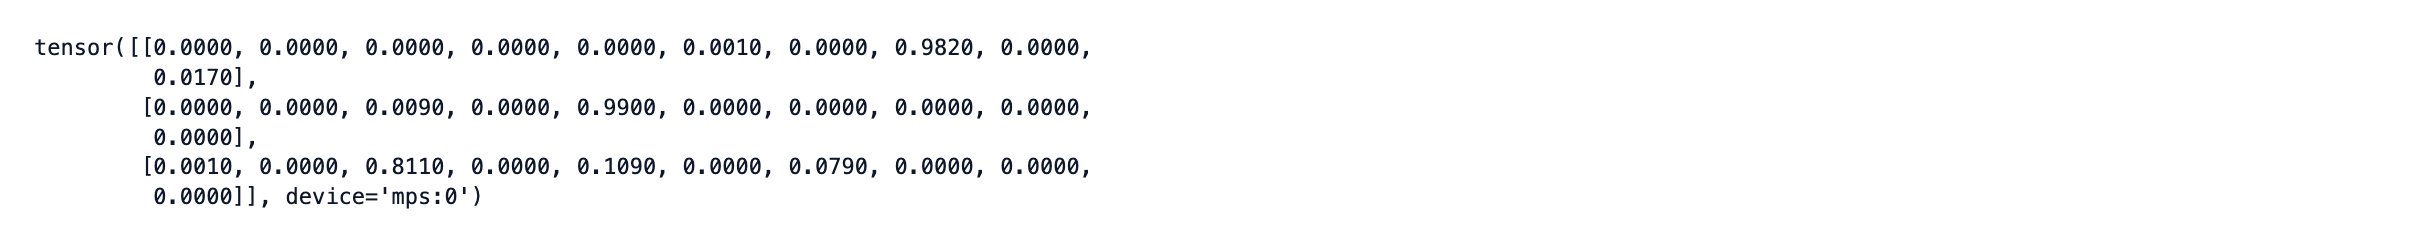

In [ ]:
import torch.nn.functional as F
y_prob = F.softmax(y_pred_logits, dim=1)
y_prob.round(decimals=3)

In [ ]:
y_top4_logits, y_top4_indices = torch.topk(y_pred_logits, k=4, dim=1)
y_top4_probs = F.softmax(y_top4_logits, dim=1)

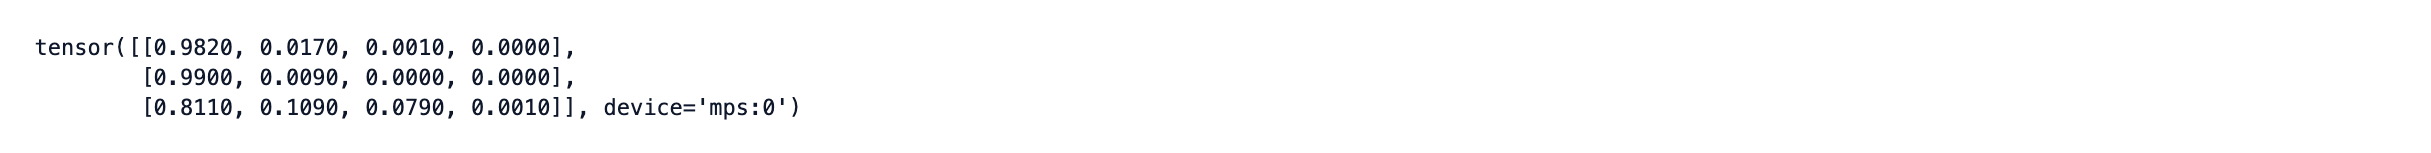

In [ ]:
y_top4_probs.round(decimals=3)

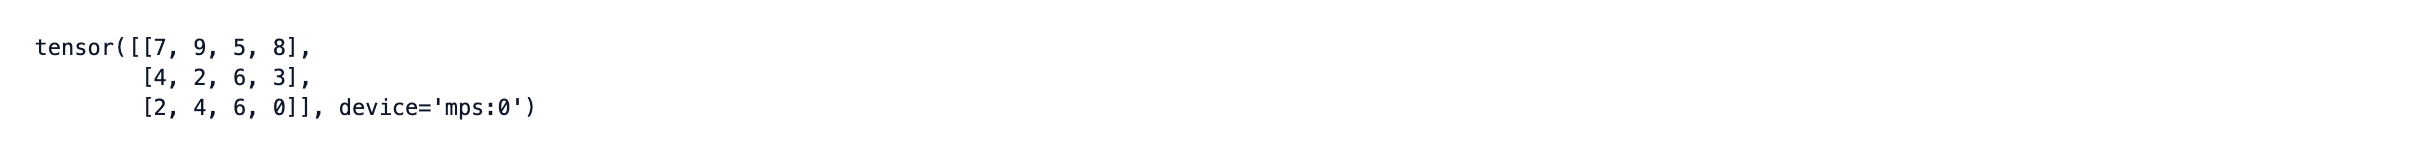

In [ ]:
y_top4_indices

In [ ]:
# Fine-tune NN hyperparameters with Optuna

import optuna

def objective(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 20, 300)
    model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=n_hidden, n_hidden2=n_hidden, n_classes=10).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    xentropy = nn.CrossEntropyLoss()
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10)
    accuracy = accuracy.to(device)
    history = train2(model, optimizer, xentropy, accuracy, fashion_train_loader, fashion_valid_loader, n_epochs=10)
    validation_accuracy = max(history["valid_metrics"])
    
    trial.report(validation_accuracy, epoch)
    if trial.should_prune():
        raise optuna.TrialPruned()
    
    return validation_accuracy    

In [ ]:
torch.manual_seed(42)
sampler = optuna.samplers.TPESampler(seed=42)

pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0, interval_steps=1)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=5)

[I 2026-05-30 12:07:46,625] A new study created in memory with name: no-name-c82168a4-0557-4f1b-b485-487865290a16


Epoch 1/10, train loss: 2.2769, train metric: 0.1471, valid metric: 0.1862


[W 2026-05-30 12:07:51,286] Trial 0 failed with parameters: {'learning_rate': 0.00031489116479568613, 'n_hidden': 287} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/guoj/github/geron-hands-on-ml/.venv/lib/python3.13/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/cw/z5jqdnvx5k15mqz1hcpwfm640000gn/T/marimo_62373/__marimo__cell_ApdJ_.py", line 13, in objective
    history = train2(model, optimizer, xentropy, accuracy, fashion_train_loader, fashion_valid_loader, n_epochs=10)
  File "/var/folders/cw/z5jqdnvx5k15mqz1hcpwfm640000gn/T/marimo_62373/__marimo__cell_BztX_.py", line 10, in train2
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                       ~~~~~~~~~~^^^^^^^^
  File "/Users/guoj/github/geron-hands-on-ml/.venv/lib/python3.13/site-packages/marimo/_runtime/handlers.py", line 51, in interrupt_handler
    raise MarimoInterrupt
Keyboard

interruption: This cell was interrupted and needs to be re-run

In [ ]:
torch.save(class_model, "fashion_mnist.pt")

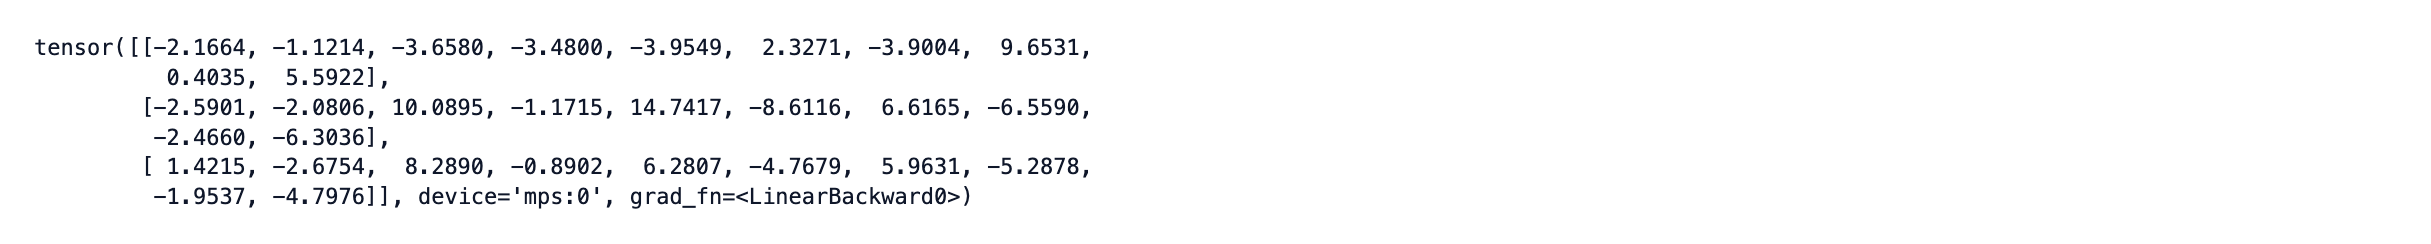

In [ ]:
loaded_model = torch.load("fashion_mnist.pt", weights_only=False)
loaded_model.eval()
loaded_model(fashion_X_new)

In [ ]:
torch.save(class_model.state_dict(), "fashion_mnist_weights.pt")

In [ ]:
# new_model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=200, n_hidden2=100, n_classes=10).to(device)
# loaded_weights = torch.load("fashion_mnist_weights.pt", weights_only=True)
# new_model.load_state_dict(loaded_weights)
# new_model.eval()
# new_model(fashion_X_new)

In [ ]:
model_data = {
    "model_state_dict": class_model.state_dict(),
    "model_hyperparameters": {
        "n_inputs": 1 * 28 * 28,
        "n_hidden1": 200,
        "n_hidden2": 100,
        "n_classes": 10
    }
}

torch.save(model_data, "fashion_mnist_model.pt")

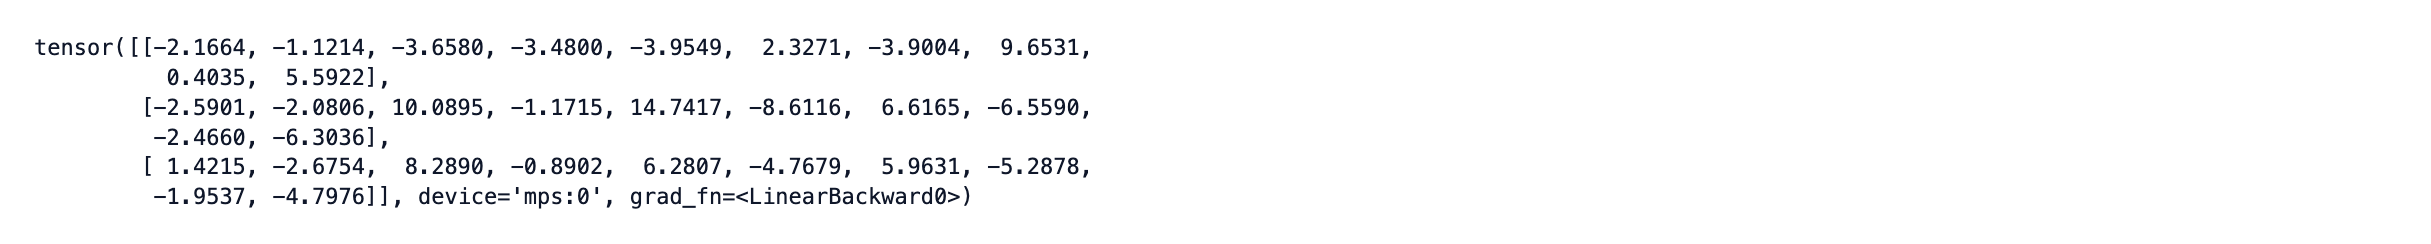

In [ ]:
loaded_data = torch.load("fashion_mnist_model.pt", weights_only=True)
new_model = ImageClassifier(**loaded_data["model_hyperparameters"]).to(device)
new_model.load_state_dict(loaded_data["model_state_dict"])
new_model.eval()
new_model(fashion_X_new)

In [ ]:
# Exercise 13

_x = torch.tensor(1.2, requires_grad=True)
_y = torch.tensor(3.4, requires_grad=True)

fxy = torch.sin(_x**2 * _y)
fxy.backward()

print(fxy)
print([_x.grad, _y.grad])

# tensor(-0.9832, grad_fn=<SinBackward0>)
# [tensor(1.4899), tensor(0.2629)]

tensor(-0.9832, grad_fn=<SinBackward0>)
[tensor(1.4899), tensor(0.2629)]


In [ ]:
# Exercise 14

class Dense(nn.Module):

    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.relu = nn.ReLU()

    def forward(self, X):
        return self.relu(self.linear(X))

In [ ]:
torch.manual_seed(42)
dense = Dense(3, 5)
_X = torch.randn(2, 3)
_y_pred = dense(_X)
_y_pred.shape
print(_y_pred)

tensor([[0.3923, 0.7557, 0.7745, 0.0300, 0.7477],
        [0.0000, 0.0000, 0.7126, 0.0534, 0.0000]], grad_fn=<ReluBackward0>)


In [ ]:
class Dense2(nn.Module):

    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        self.bias = nn.Parameter(torch.zeros(out_features))

    def forward(self, X):
        z = X @ self.weight.T + self.bias
        return F.relu(z)

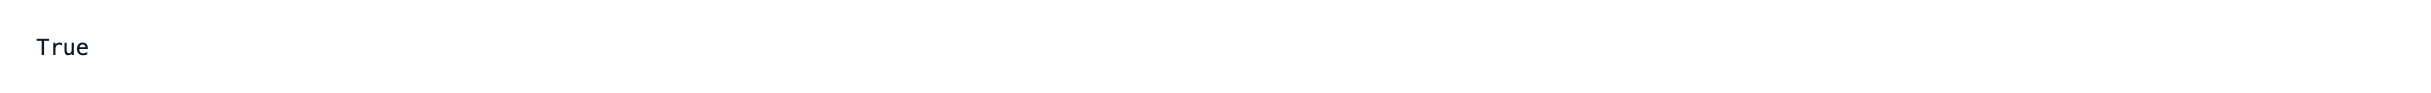

In [ ]:
torch.manual_seed(42)
dense2 = Dense2(3, 5)
_X = torch.randn(2, 3)
y_pred2 = dense2(_X)
y_pred2.shape

y_pred2_check = F.relu(_X @ dense2.weight.T + dense2.bias)
torch.allclose(y_pred2, y_pred2_check)

In [ ]:
# Exercise 15

from sklearn.datasets import fetch_covtype
covtype = fetch_covtype(data_home="datasets/")

In [ ]:
# Normalization

X_covtype = torch.tensor(covtype.data, dtype=torch.float32)
covtype_means = X_covtype.mean(dim=0, keepdim=True)
covtype_stds = X_covtype.std(dim=0, keepdim=True)
X_std_covtype = (X_covtype - covtype_means) / covtype_stds

# Target: 0 -- 6
y_covtype = torch.tensor(covtype.target - 1, dtype=torch.long)

covtype_dataset = TensorDataset(X_std_covtype, y_covtype)

In [ ]:
# Dataloader

from torch.utils.data import random_split

torch.manual_seed(42)

batch_size = 256

train_size = len(covtype_dataset) * 80 // 100
valid_size = len(covtype_dataset) * 10 // 100
test_size = len(covtype_dataset) - train_size - valid_size

cov_train_dataset, cov_valid_dataset, cov_test_dataset = random_split(
    covtype_dataset,
    [train_size, valid_size, test_size]
)

covtype_train_loader = DataLoader(cov_train_dataset, batch_size=batch_size, shuffle=True)
covtype_valid_loader = DataLoader(cov_valid_dataset, batch_size=batch_size)
covtype_test_loader = DataLoader(cov_test_dataset, batch_size=batch_size)

In [ ]:
class CovtypeClassifier(nn.Module):

    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(54, 300),
            nn.ReLU(),
            nn.Linear(300, 100),
            nn.ReLU(),
            nn.Linear(100, 7)
        )

    def forward(self, X):
        return self.mlp(X)

In [ ]:
torch.manual_seed(42)
covtype_model = CovtypeClassifier().to(device)

cov_opt = torch.optim.SGD(covtype_model.parameters(), lr=0.05)
criterion = nn.CrossEntropyLoss()
metric = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=7
).to(device)
_ = train2(covtype_model, cov_opt, criterion, metric, covtype_train_loader, covtype_valid_loader, 20)

Epoch 1/20, train loss: 0.6895, train metric: 0.7195, valid metric: 0.7484
Epoch 2/20, train loss: 0.5726, train metric: 0.7570, valid metric: 0.7661
Epoch 3/20, train loss: 0.5335, train metric: 0.7720, valid metric: 0.7785
Epoch 4/20, train loss: 0.5058, train metric: 0.7845, valid metric: 0.7875
Epoch 5/20, train loss: 0.4849, train metric: 0.7938, valid metric: 0.8028
Epoch 6/20, train loss: 0.4657, train metric: 0.8035, valid metric: 0.8116
Epoch 7/20, train loss: 0.4480, train metric: 0.8116, valid metric: 0.7865
Epoch 8/20, train loss: 0.4335, train metric: 0.8186, valid metric: 0.7703
Epoch 9/20, train loss: 0.4212, train metric: 0.8243, valid metric: 0.8167
Epoch 10/20, train loss: 0.4085, train metric: 0.8300, valid metric: 0.8272
Epoch 11/20, train loss: 0.3977, train metric: 0.8351, valid metric: 0.8252
Epoch 12/20, train loss: 0.3892, train metric: 0.8395, valid metric: 0.8442
Epoch 13/20, train loss: 0.3800, train metric: 0.8431, valid metric: 0.8081
Epoch 14/20, train lo

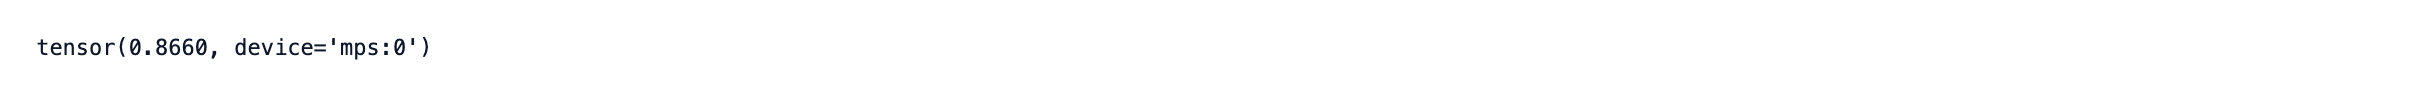

In [ ]:
evaluate_tm(covtype_model, covtype_test_loader, metric)